In [1]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
matches = pd.read_csv('matches.csv')
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
deliveries= pd.read_csv('deliveries.csv')
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
matches.shape

(1095, 20)

In [5]:
deliveries.shape

(260920, 17)

In [6]:
matches.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1095.0,NaN,NaN,NaN,904828.319635,367740.242299,335982.0,548331.5,980961.0,1254062.5,1426312.0
season,1095,17,2013,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1044,36,Mumbai,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,1095,823,2008-04-19,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_type,1095,8,League,1029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
player_of_match,1090,291,AB de Villiers,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
venue,1095,58,Eden Gardens,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team1,1095,19,Royal Challengers Bangalore,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team2,1095,19,Mumbai Indians,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_winner,1095,19,Mumbai Indians,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
deliveries.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
match_id,260920.0,NaN,NaN,NaN,907066.506086,367991.278255,335982.0,548334.0,980967.0,1254066.0,1426312.0
inning,260920.0,NaN,NaN,NaN,1.483531,0.502643,1.0,1.0,1.0,2.0,6.0
batting_team,260920,19,Mumbai Indians,31437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bowling_team,260920,19,Mumbai Indians,31505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
over,260920.0,NaN,NaN,NaN,9.197677,5.683484,0.0,4.0,9.0,14.0,19.0
ball,260920.0,NaN,NaN,NaN,3.624486,1.81492,1.0,2.0,4.0,5.0,11.0
batter,260920,673,V Kohli,6236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bowler,260920,530,R Ashwin,4679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
non_striker,260920,663,V Kohli,6067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
batsman_runs,260920.0,NaN,NaN,NaN,1.265001,1.639298,0.0,0.0,1.0,1.0,6.0


In [8]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [9]:
deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       14125 non-null   str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  12950 non-null   str  
 15  dismissal_kind    12950 non-null   str  
 16  fielder           9354 non-null    str  
dtypes: int64(8), str(9)
m

In [10]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [11]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [12]:
matches['winner'].fillna('No Result', inplace=True)
matches['player_of_match'].fillna('No Award', inplace=True)
matches['city'].fillna('Unknown', inplace=True)


0        Bangalore
1       Chandigarh
2            Delhi
3           Mumbai
4          Kolkata
           ...    
1090     Hyderabad
1091     Ahmedabad
1092     Ahmedabad
1093       Chennai
1094       Chennai
Name: city, Length: 1095, dtype: str

In [13]:
matches['result_margin'].fillna(0, inplace=True)
matches['target_runs'].fillna(0, inplace=True)
matches['target_overs'].fillna(0, inplace=True)

0       20.0
1       20.0
2       20.0
3       20.0
4       20.0
        ... 
1090    20.0
1091    20.0
1092    20.0
1093    20.0
1094    20.0
Name: target_overs, Length: 1095, dtype: float64

In [14]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [15]:
matches['date'] = pd.to_datetime(matches['date'])

In [16]:
for col in ['team1','team2','toss_winner','winner']:
    matches[col] = matches[col].str.strip()

In [23]:
team_replacements = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Deccan Chargers': 'Sunrisers Hyderabad'
}

for col in ['team1','team2','toss_winner','winner']:
    matches[col] = matches[col].replace(team_replacements)

Team Dominance Across Seasons

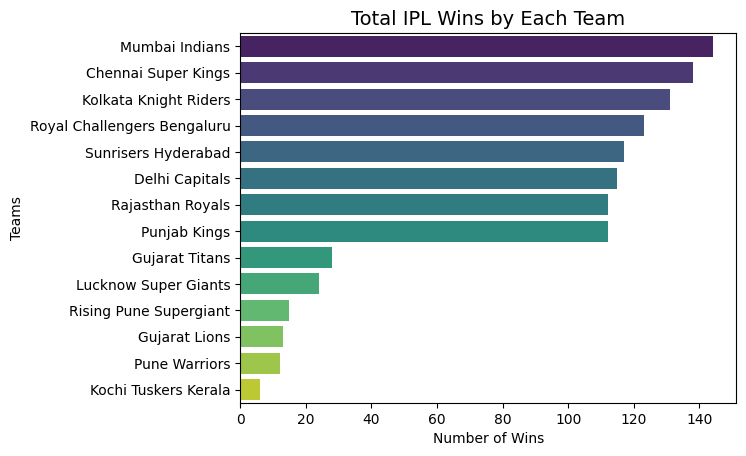

In [24]:
team_wins = matches['winner'].value_counts()

sns.barplot(
    x=team_wins.values,
    y=team_wins.index,
    palette="viridis"
)
plt.title('Total IPL Wins by Each Team', fontsize=14)
plt.xlabel('Number of Wins')
plt.ylabel('Teams')
plt.show()